# DATA 606 Capstone Deliverable: Comprehensive EDA

**Author:** Brett Allen (ballen3@umbc.edu)

**Topic:** Air Traffic Controller (ATC) Communications Intelligence

*Speech Recognition and Information Extraction for Aviation Safety*

## Setup

In [1]:
!python --version

Python 3.12.9


In [2]:
!cat ../requirements.txt

# Python 3.12.4
datasets==3.2.0
transformers==4.57.6
librosa==1.0.0
soundfile==0.14.0
coverage>=7.7.0  # numba's coverage integration needs coverage.types.Tracer (added in 7.7.0)
pandas==2.3.3
numpy==2.5.3
matplotlib==3.10.6
seaborn==0.13.2
scipy==1.18.1



In [3]:
!python -m pip install -q -r ../requirements.txt

### Imports

In [4]:
%load_ext autoreload
%autoreload 2

from datasets import load_dataset, DatasetDict, disable_progress_bars
import os
import io
import base64
import html as html_lib
import sys
from IPython.display import HTML, display
import soundfile as sf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display

# Make the reusable pipeline code in ../src importable from the notebook.
sys.path.append(os.path.join(os.getcwd(), "..", "src"))
from preprocessing import DataIngestPipeline

### Configurations

In [23]:
RANDOM_SEED = 42

In [5]:
%matplotlib inline
sns.set_theme(style="whitegrid")
disable_progress_bars()  # keep re-runs free of noisy download/map/cast tqdm output

# Saving EDA visualizations locally for further analysis.
FIGURES_DIR = os.path.join(os.getcwd(), "..", "res", "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)


def save_fig(fig, name, dpi=150):
    """Save a matplotlib figure to res/figures/<name>.png for reuse in slides."""
    path = os.path.join(FIGURES_DIR, f"{name}.png")
    fig.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Saved figure: {os.path.relpath(path, os.getcwd())}")
    return path


# Saving audio samples locally for further analysis.
AUDIO_SAMPLES_DIR = os.path.join(os.getcwd(), "..", "res", "audio_samples")
os.makedirs(AUDIO_SAMPLES_DIR, exist_ok=True)

In [6]:
data_dir = "../data/"

## Data Ingestion
As part of the proposal EDA process, we looked at two different datasets. The first dataset is the ATCO2-ASR which contains real ATC communications audio. The second dataset is the ATCOSIM which contains simulated data. Both datasets were obtained from Huggingface and joined together along with metadata to identify origin source. Since the ATCO2-ASR dataset represents real ATC communications, it has the possibility of having distortion and noise while the ATCOSIM dataset is always clear and easier to comprehend with no such noise. However, both datasets have speakers with accents which may present as bias when validating the trained model(s) against ATC audio without such accents. 

In this comprehensive EDA process, we introduce the ATC-ASR-Dataset as a third dataset to supplement the real ATCO2-ASR dataset (see https://huggingface.co/datasets/jacktol/ATC-ASR-Dataset). According to the publisher of this dataset, Jacktol: "ATC ASR Dataset is a high-quality, fine-tuning-ready speech recognition dataset constructed from two real-world Air Traffic Control (ATC) corpora: the UWB ATC Corpus and the ATCO2 1-Hour Test Subset." Both datasets feature real ATC utterences just like the ATCO2-ASR dataset.

In [7]:
atco2_asr_path = os.path.join(data_dir, "raw/atco2-asr")
atcosim_path = os.path.join(data_dir, "raw/atcosim")
atc_asr_dataset_path = os.path.join(data_dir, "raw/atc-asr-dataset")

print(f"atco2_asr_path       : {atco2_asr_path}")
print(f"atcosim_path         : {atcosim_path}")
print(f"atc_asr_dataset_path : {atc_asr_dataset_path}")

atco2_asr_path       : ../data/raw/atco2-asr
atcosim_path         : ../data/raw/atcosim
atc_asr_dataset_path : ../data/raw/atc-asr-dataset


### ATCO2-ASR Dataset

In [8]:
atco2_asr_dataset = load_dataset("jlvdoorn/atco2-asr", cache_dir=atco2_asr_path)

In [9]:
atco2_asr_dataset.keys()

dict_keys(['train', 'validation'])

In [10]:
n_train = len(atco2_asr_dataset['train'])
n_val = len(atco2_asr_dataset['validation'])
total = n_train + n_val
print(f"Number of training samples   : {n_train} ({n_train/total:.2%})")
print(f"Number of validation samples : {n_val} ({n_val/total:.2%})")
print(f"Total number of samples      : {total}")
print(f"Split ratio (train:val)      : {n_train/n_val:.2f}")

Number of training samples   : 446 (79.79%)
Number of validation samples : 113 (20.21%)
Total number of samples      : 559
Split ratio (train:val)      : 3.95


In [11]:
# Inspect the first training sample to see what the data looks like.
atco2_asr_dataset['train'][0]

{'audio': {'path': 'LKPR_RUZYNE_Radar_120_520MHz_20201025_091112.wav',
  'array': array([ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
         -6.10351562e-05, -6.10351562e-05, -6.10351562e-05], shape=(117760,)),
  'sampling_rate': 16000},
 'text': 'Oscar Kilo Papa Mike Bravo descend flight level one hundred level one hundred Oscar Kilo Papa Mike Bravo ',
 'info': 'LKPR\nPraha Ruzyne\nRadar\nAKEVA ARVEG BAGRU BAROX BAVIN BEKVI ELMEK ELPON ERASU EVEMI KENOK KUVIX LETNA RATEV RISUK SOMIS SULOV TIPRU UTORO\nBLA131 BLA1XQ BTI7PY CTN480 DLH3NL DLH9TP ETD72E EWG6HP FIN1DH IRA711 KLM44K MLD863 MLD864 OKHBT OKLLZ OKMHZ OKPHM OKWUS17 OKYAI14 RYR1JU RYR4945 SXS7D THY32B THY6577 TIE790J UAE73  \nAll Charter Air Baltic Croatia Lufthansa Etihad Eurowings Finn Iranair Klm Moldova Oklahoma Okapi Alfa Ryan Sunexpress Turkish Time Emirates'}

In [12]:
# Get a unique count of sample rates to verify that sample rate is always 16kHz for atco2-asr dataset
# Iterate through the dataset and get the sample rate for each audio file
unique_sample_rates = set()
for split in atco2_asr_dataset.keys():
    for sample in atco2_asr_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in atco2_asr_dataset: {unique_sample_rates}")

Unique sample rates in atco2_asr_dataset: {16000}


### ATCOSIM Dataset

In [13]:
atcosim_dataset = load_dataset("jlvdoorn/atcosim", cache_dir=atcosim_path)

In [14]:
atcosim_dataset.keys()

dict_keys(['train', 'validation'])

In [15]:
n_train = len(atcosim_dataset['train'])
n_val = len(atcosim_dataset['validation'])
total = n_train + n_val
print(f"Number of training samples   : {n_train} ({n_train/total:.2%})")
print(f"Number of validation samples : {n_val} ({n_val/total:.2%})")
print(f"Total number of samples      : {total}")
print(f"Split ratio (train:val)      : {n_train/n_val:.2f}")

Number of training samples   : 7646 (79.99%)
Number of validation samples : 1913 (20.01%)
Total number of samples      : 9559
Split ratio (train:val)      : 4.00


In [16]:
# Inspect the first training sample to see what the data looks like.
atcosim_dataset['train'][0]

{'audio': {'path': 'gf1_01_001.wav',
  'array': array([ 6.10351562e-05, -3.05175781e-05,  3.05175781e-05, ...,
         -1.95922852e-02, -6.31713867e-03, -9.76562500e-04], shape=(93955,)),
  'sampling_rate': 32000},
 'text': ' contact geneva one two eight decimal one five good bye '}

In [17]:
# Get a unique count of sample rates to verify that sample rate is always 32kHz for atcosim dataset
# Iterate through the dataset and get the sample rate for each audio file
unique_sample_rates = set()
for split in atcosim_dataset.keys():
    for sample in atcosim_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in atcosim_dataset: {unique_sample_rates}")

Unique sample rates in atcosim_dataset: {32000}


### ATC-ASR Dataset

In [18]:
atc_asr_dataset = load_dataset("jacktol/ATC-ASR-Dataset", cache_dir=atc_asr_dataset_path)

In [19]:
atc_asr_dataset.keys()

dict_keys(['train', 'validation', 'test'])

In [20]:
n_train = len(atc_asr_dataset['train'])
n_val = len(atc_asr_dataset['validation'])
n_test = len(atc_asr_dataset['test'])
total = n_train + n_val + n_test
print(f"Number of training samples   : {n_train} ({n_train/total:.2%})")
print(f"Number of validation samples : {n_val} ({n_val/total:.2%})")
print(f"Number of test samples       : {n_test} ({n_test/total:.2%})")
print(f"Total number of samples      : {total}")

Number of training samples   : 6497 (79.99%)
Number of validation samples : 812 (10.00%)
Number of test samples       : 813 (10.01%)
Total number of samples      : 8122


In [21]:
# Inspect the first training sample to see what the data looks like.
atc_asr_dataset['train'][0]

{'id': '0023HAQRADETCJDF66RO',
 'audio': {'path': '0023HAQRADETCJDF66RO.wav',
  'array': array([-0.00024414, -0.00061035, -0.00112915, ...,  0.00018311,
          0.00030518,  0.00021362], shape=(22720,)),
  'sampling_rate': 16000},
 'text': 'SIERRA DELTA MIKE'}

In [22]:
# Get a unique count of sample rates to verify that sample rate is always 16kHz for atc asr dataset
# Iterate through the dataset and get the sample rate for each audio file
unique_sample_rates = set()
for split in atc_asr_dataset.keys():
    for sample in atc_asr_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in atc_asr_dataset: {unique_sample_rates}")

Unique sample rates in atc_asr_dataset: {16000}


## Pipeline Prototyping

With all three raw sources loaded and inspected above, this section builds the utility
functions the join/cleaning step right after this needs: transcript normalization and proxy
feature extraction, acoustic feature extraction, data-quality checks, schema validation, and
the session-safe re-split logic. They're prototyped directly in cells here, against real
samples pulled from the datasets already loaded above (seed 42, so the same rows come up every
run), the way this pipeline was actually built before it got promoted into
`../src/preprocessing/` for reuse. `DataIngestPipeline`, used in the Join Datasets step right
after this section, runs the same logic; a later notebook for model development will import
that module directly rather than re-deriving it here.

The fixed vocabulary/column-name tables a couple of these functions depend on
(`preprocessing.vocab`, `FINAL_UTTERANCE_COLUMNS`) are imported as-is: they're plain data
tables, not pipeline logic worth re-typing by hand.

In [24]:
rng = np.random.default_rng(RANDOM_SEED)

atco2_idx = int(rng.integers(len(atco2_asr_dataset["train"])))
atcosim_idx = int(rng.integers(len(atcosim_dataset["train"])))
atc_asr_idx = int(rng.integers(len(atc_asr_dataset["train"])))

sample_atco2 = atco2_asr_dataset["train"][atco2_idx]
sample_atcosim = atcosim_dataset["train"][atcosim_idx]
sample_atc_asr = atc_asr_dataset["train"][atc_asr_idx]

print(f"ATCO2-ASR       [{atco2_idx}]: {sample_atco2['text']!r}")
print(f"ATCOSIM         [{atcosim_idx}]: {sample_atcosim['text']!r}")
print(f"ATC-ASR-Dataset [{atc_asr_idx}]: {sample_atc_asr['text']!r}")

ATCO2-ASR       [39]: 'Kilo Lima Papa Victor standby for runway zero nine for now follow Tumka Four Charlie arrival due to departure from Brno '
ATCOSIM         [5917]: 'good morning lufthansa four seven three one radar contact maintain flight level three four zero continue present heading until advised '
ATC-ASR-Dataset [4252]: 'TOWER LUFTHANSA TWO HOTEL TANGO HELLO ESTABLISH THREE ONE'


### Transcript normalization and proxy counts

`text_features.py`'s job: lowercase/strip punctuation, then count three lightweight proxies
(numeral tokens, ATC command verbs, callsign-like sequences) against fixed vocabulary tables in
`preprocessing.vocab`.

In [26]:
import re

_PUNCTUATION_RE = re.compile(r"[^\w\s]")
_WHITESPACE_RE = re.compile(r"\s+")


def normalize_transcript(text):
    """Lowercase + strip punctuation + collapse whitespace."""
    text = text or ""
    text = _PUNCTUATION_RE.sub(" ", text.lower())
    return _WHITESPACE_RE.sub(" ", text).strip()

In [ ]:
# Iterate test cases and inspect raw vs normalized
for name, sample in [
    ("ATCO2-ASR", sample_atco2), ("ATCOSIM", sample_atcosim), ("ATC-ASR-Dataset", sample_atc_asr)
]:
    print(name)
    print(f"  raw       : {sample['text']!r}")
    print(f"  normalized: {normalize_transcript(sample['text'])!r}")

ATCO2-ASR
  raw       : 'Kilo Lima Papa Victor standby for runway zero nine for now follow Tumka Four Charlie arrival due to departure from Brno '
  normalized: 'kilo lima papa victor standby for runway zero nine for now follow tumka four charlie arrival due to departure from brno'
ATCOSIM
  raw       : 'good morning lufthansa four seven three one radar contact maintain flight level three four zero continue present heading until advised '
  normalized: 'good morning lufthansa four seven three one radar contact maintain flight level three four zero continue present heading until advised'
ATC-ASR-Dataset
  raw       : 'TOWER LUFTHANSA TWO HOTEL TANGO HELLO ESTABLISH THREE ONE'
  normalized: 'tower lufthansa two hotel tango hello establish three one'


In [ ]:
from preprocessing.vocab import (
    ATC_NUMERAL_WORDS,
    ATC_COMMAND_VERBS,
    ITU_PHONETIC_ALPHABET,
    KNOWN_CALLSIGN_WORDS,
)

_ANCHOR_VOCAB = ITU_PHONETIC_ALPHABET | KNOWN_CALLSIGN_WORDS
_CALLSIGN_VOCAB = _ANCHOR_VOCAB | ATC_NUMERAL_WORDS


def count_numeric_tokens(normalized_text):
    return sum(1 for token in normalized_text.split() if token in ATC_NUMERAL_WORDS)


def count_command_verbs(normalized_text):
    return sum(1 for token in normalized_text.split() if token in ATC_COMMAND_VERBS)


def count_callsign_like_sequences(normalized_text):
    """Count runs of 2+ consecutive tokens drawn from {phonetic alphabet, known airline
    words, numeral words}, requiring at least one non-numeral *anchor* token per run so a
    pure numeric readback (e.g. a frequency) isn't mistaken for a callsign.
    """
    tokens = normalized_text.split()
    count = 0
    run_length = 0
    run_has_anchor = False
    for token in tokens + [None]:
        if token in _CALLSIGN_VOCAB:
            run_length += 1
            run_has_anchor = run_has_anchor or token in _ANCHOR_VOCAB
        else:
            if run_length >= 2 and run_has_anchor:
                count += 1
            run_length = 0
            run_has_anchor = False
    return count


pd.DataFrame(
    [
        {
            "source": name,
            "normalized": (n := normalize_transcript(sample["text"])),
            "numeric_token_count": count_numeric_tokens(n),
            "command_verb_count": count_command_verbs(n),
            "callsign_like_count": count_callsign_like_sequences(n),
        }
        for name, sample in [
            ("ATCO2-ASR", sample_atco2),
            ("ATCOSIM", sample_atcosim),
            ("ATC-ASR-Dataset", sample_atc_asr),
        ]
    ]
)

**Worth noticing:** the ATC-ASR-Dataset sample above gets `command_verb_count = 0` even though
it contains "ESTABLISH" ("...HELLO ESTABLISH THREE ONE"). `ATC_COMMAND_VERBS` includes
`"established"` (the participle, closer to how ATCOSIM tends to phrase it) but not the bare
verb `"establish"`, so this real row falls straight through a gap in the fixed vocabulary.
That's exactly what this proxy is: a rough, comparative signal, not a validated phraseology
parser (see the module docstring and Section 3.3 in `docs/report.md`).

### Acoustic features

`audio_features.py`'s job: derive six summary features from one decoded waveform. Tested first
against two synthetic edge cases with a known, hand-computable answer (silence, a pure tone),
then against a real decoded clip from the ATCOSIM sample above.

In [ ]:
FRAME_LENGTH = 2048
HOP_LENGTH = 512
SILENCE_TOP_DB = 30
SNR_NOISE_PERCENTILE = 10
SNR_SIGNAL_PERCENTILE = 95

FEATURE_NAMES = (
    "rms_energy", "silence_pct", "snr_db_proxy",
    "zero_crossing_rate", "spectral_centroid_hz", "spectral_bandwidth_hz",
)


def compute_acoustic_features(y, sr):
    """Derive six acoustic summary features from one decoded mono waveform. Returns NaN for
    every feature if `y` is empty/degenerate rather than raising.
    """
    y = np.asarray(y, dtype=np.float32)
    if y.size == 0 or not sr:
        return {name: float("nan") for name in FEATURE_NAMES}

    rms_frames = librosa.feature.rms(y=y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0]
    rms_energy = float(np.mean(rms_frames))

    non_silent_intervals = librosa.effects.split(
        y, top_db=SILENCE_TOP_DB, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH
    )
    if len(non_silent_intervals) == 0:
        silence_pct = 100.0
    else:
        non_silent_samples = sum(end - start for start, end in non_silent_intervals)
        silence_pct = float(100 * (1 - non_silent_samples / len(y)))

    frame_db = librosa.amplitude_to_db(rms_frames, ref=1.0)
    snr_db_proxy = float(
        np.percentile(frame_db, SNR_SIGNAL_PERCENTILE) - np.percentile(frame_db, SNR_NOISE_PERCENTILE)
    )

    zero_crossing_rate = float(
        np.mean(librosa.feature.zero_crossing_rate(y, frame_length=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
    )

    spectral_centroid_hz = float(
        np.mean(librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
    )
    spectral_bandwidth_hz = float(
        np.mean(librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=FRAME_LENGTH, hop_length=HOP_LENGTH)[0])
    )

    return {
        "rms_energy": rms_energy,
        "silence_pct": silence_pct,
        "snr_db_proxy": snr_db_proxy,
        "zero_crossing_rate": zero_crossing_rate,
        "spectral_centroid_hz": spectral_centroid_hz,
        "spectral_bandwidth_hz": spectral_bandwidth_hz,
    }

In [ ]:
t = np.linspace(0, 0.5, 8000, endpoint=False)
tone = (0.5 * np.sin(2 * np.pi * 440 * t)).astype(np.float32)  # 0.5s, 440Hz, known-clean tone
silence = np.zeros(8000, dtype=np.float32)  # 0.5s of digital silence

waveforms = {
    "440Hz tone (synthetic)": (tone, 16000),
    "digital silence (synthetic)": (silence, 16000),
    f"ATCOSIM sample [{atcosim_idx}] (real)": (
        np.asarray(sample_atcosim["audio"]["array"], dtype=np.float32),
        sample_atcosim["audio"]["sampling_rate"],
    ),
}

pd.DataFrame({name: compute_acoustic_features(y, sr=sr) for name, (y, sr) in waveforms.items()}).T

Worth noticing: `silence_pct` is **0.0** for the uniform digital-silence clip, not 100.
`librosa.effects.split` thresholds each frame relative to the loudest frame in the clip, and a
perfectly uniform (all-zero) clip has nothing quieter than its own max, so it gets treated as
one fully non-silent interval. That's a real quirk of this relative-threshold silence detector,
worth knowing before trusting `silence_pct` on a clip with little dynamic range.

### Data-quality checks

`quality.py`'s job: flag/drop rows on a `utterance_df`-shaped table. That table doesn't exist
yet at this point in the notebook (it's only built by the join step below), so a small
hand-built table stands in for it here, one deliberate problem per row: a blank `audio_path`,
a blank `transcript`, a negative `duration_sec`, a true duplicate of row 0, and a
repeated-but-distinct transcript.

In [ ]:
from dataclasses import dataclass
from typing import Literal


@dataclass
class QualityCheckResult:
    name: str
    description: str
    mask: pd.Series  # boolean, aligned to the df it was computed against; True = flagged
    action: Literal["drop", "flag_only"]
    notes: str = ""


def check_missing_audio(df):
    mask = (
        df["audio_path"].isna()
        | (df["audio_path"].astype(str).str.strip() == "")
        | df["audio_decode_error"].notna()
    )
    return QualityCheckResult(
        "missing_audio", "Audio path is null/blank, or the row's audio failed to decode.",
        mask, "drop", "Rows with no usable audio can't be used for ASR training or acoustic feature EDA.",
    )


def check_missing_transcript(df):
    mask = df["transcript"].isna() | (df["transcript"].astype(str).str.strip() == "")
    return QualityCheckResult(
        "missing_transcript", "Transcript is null or blank after stripping whitespace.",
        mask, "drop", "Rows with no transcript can't be used for ASR training or text feature EDA.",
    )


def check_zero_or_negative_duration(df):
    mask = df["duration_sec"].isna() | (df["duration_sec"] <= 0)
    return QualityCheckResult(
        "zero_or_negative_duration", "Derived audio duration is missing, zero, or negative.",
        mask, "drop", "A non-positive duration means the audio decode produced no usable samples.",
    )


def check_corrupt_audio(df):
    mask = df["audio_decode_error"].notna()
    return QualityCheckResult(
        "corrupt_audio", "Audio failed to decode (see `audio_decode_error` for the exception).",
        mask, "drop", "Kept separate from `missing_audio` so the cleaning log shows *why* audio was unusable.",
    )


def check_duplicate_row(df):
    mask = df.duplicated(subset=["audio_checksum", "transcript_normalized"], keep="first")
    return QualityCheckResult(
        "duplicate_row", "Same audio content AND same normalized transcript as an earlier row.",
        mask, "drop", "A true accidental duplicate, distinct from repeated_transcript below.",
    )


def check_repeated_transcript(df):
    same_text = df.duplicated(subset=["transcript_normalized"], keep=False)
    same_audio_and_text = df.duplicated(subset=["audio_checksum", "transcript_normalized"], keep=False)
    mask = same_text & ~same_audio_and_text
    return QualityCheckResult(
        "repeated_transcript", "Same normalized transcript as another row, but different audio content.",
        mask, "flag_only", "Fixed ATC phraseology recurring across distinct recordings; retained, not dropped.",
    )


DEFAULT_QUALITY_CHECKS = [
    check_missing_audio, check_missing_transcript, check_zero_or_negative_duration,
    check_corrupt_audio, check_duplicate_row, check_repeated_transcript,
]


def run_quality_checks(df, checks=None):
    """Apply `checks` in order, each against the rows still surviving after prior 'drop'
    stages, and return `(cleaned_df, dropped_df, cleaning_log_df)`.
    """
    checks = checks if checks is not None else DEFAULT_QUALITY_CHECKS
    working = df.copy()
    log_rows = []
    dropped_frames = []

    for check in checks:
        result = check(working)
        rows_in = len(working)
        rows_flagged = int(result.mask.sum())

        if result.action == "drop":
            if rows_flagged:
                dropped_frames.append(
                    working.loc[result.mask].assign(dropped_by=result.name, drop_reason=result.notes)
                )
            working = working.loc[~result.mask]
            rows_removed = rows_flagged
        else:
            working[f"is_{result.name}"] = False
            working.loc[result.mask, f"is_{result.name}"] = True
            if result.name == "repeated_transcript":
                working["repeated_transcript_count"] = working.groupby("transcript_normalized")[
                    "transcript_normalized"
                ].transform("count")
            rows_removed = 0

        log_rows.append(
            {
                "stage": result.name, "check_description": result.description, "rows_in": rows_in,
                "rows_flagged": rows_flagged, "rows_removed": rows_removed, "rows_out": len(working),
                "action": result.action, "notes": result.notes,
            }
        )

    cleaning_log_df = pd.DataFrame(log_rows)
    if dropped_frames:
        dropped_df = pd.concat(dropped_frames, ignore_index=True)
    else:
        dropped_df = df.iloc[0:0].assign(dropped_by=[], drop_reason=[])

    return working.reset_index(drop=True), dropped_df, cleaning_log_df

In [ ]:
toy_utterances = pd.DataFrame(
    {
        "audio_path": ["a.wav", "b.wav", "", "d.wav", "e.wav"],
        "audio_decode_error": [None, None, None, None, None],
        "transcript": ["roger", "roger", "standby", "", "standby"],
        "duration_sec": [1.2, 1.2, 0.8, 2.0, -1.0],
        "audio_checksum": ["c1", "c1", "c3", "c4", "c5"],
        "transcript_normalized": ["roger", "roger", "standby", "", "standby"],
    }
)

toy_utterances.assign(
    missing_audio=check_missing_audio(toy_utterances).mask,
    missing_transcript=check_missing_transcript(toy_utterances).mask,
    zero_or_negative_duration=check_zero_or_negative_duration(toy_utterances).mask,
    duplicate_row=check_duplicate_row(toy_utterances).mask,
    repeated_transcript=check_repeated_transcript(toy_utterances).mask,
)

In [ ]:
cleaned, dropped, log = run_quality_checks(toy_utterances)

print("cleaned (survives every check):")
display(cleaned)

print("\ndropped (every row a 'drop' check removed, tagged with why):")
display(dropped[["audio_path", "transcript", "duration_sec", "dropped_by", "drop_reason"]])

print("\ncleaning log (stage-by-stage):")
display(log[["stage", "rows_in", "rows_flagged", "rows_removed", "rows_out"]])

### Schema validation

`schema.py`'s job: assert `utterance_df`'s columns match the documented data dictionary
exactly, so a retired column sneaking back in (or a typo silently omitting one) gets caught
immediately rather than discovered downstream.

In [ ]:
from preprocessing.schema import FINAL_UTTERANCE_COLUMNS


def validate_final_schema(df):
    """Raise if `df`'s columns don't match `FINAL_UTTERANCE_COLUMNS` exactly."""
    expected = set(FINAL_UTTERANCE_COLUMNS)
    actual = set(df.columns)
    missing = expected - actual
    unexpected = actual - expected
    assert not missing and not unexpected, (
        f"utterance_df schema drift -- missing columns: {sorted(missing) or 'none'}; "
        f"unexpected columns: {sorted(unexpected) or 'none'}."
    )


good_df = pd.DataFrame(columns=FINAL_UTTERANCE_COLUMNS)
validate_final_schema(good_df)
print("Passed: columns match FINAL_UTTERANCE_COLUMNS exactly.")

In [ ]:
bad_df = pd.DataFrame(columns=[c for c in FINAL_UTTERANCE_COLUMNS if c != "duration_sec"] + ["extra_col"])
try:
    validate_final_schema(bad_df)
except AssertionError as e:
    print("Raised, as expected, with a message naming exactly what's wrong:")
    print(e)

### Session-safe re-splitting

`ingest.py`'s job here: parse a recording timestamp out of a filename where one is embedded,
and group ATCOSIM's `<speaker>_<session>_<utterance>.wav` filenames by recording session so
`_resplit` (used in the Join Datasets step below) can keep every session's rows in a single
train/validation/test split, with no session straddling a boundary.

In [ ]:
from datetime import datetime

_RECORDING_TIMESTAMP_RE = re.compile(r"(\d{8})_(\d{6})")


def _parse_recorded_at(audio_path):
    """Parse a `YYYYMMDD_HHMMSS` timestamp out of an audio filename, if present."""
    if not audio_path:
        return None
    match = _RECORDING_TIMESTAMP_RE.search(audio_path)
    if not match:
        return None
    try:
        return datetime.strptime(match.group(0), "%Y%m%d_%H%M%S").isoformat()
    except ValueError:
        return None


for name, sample in [
    ("ATCO2-ASR", sample_atco2), ("ATCOSIM", sample_atcosim), ("ATC-ASR-Dataset", sample_atc_asr)
]:
    path = sample["audio"]["path"]
    print(f"{name:16s} {path:60s} -> {_parse_recorded_at(path)}")

In [ ]:
from pathlib import Path

_SESSION_KEY_PATTERNS = {"atcosim": re.compile(r"^(.+)_\d+$")}


def _session_group(audio_path, pattern):
    """Return `audio_path`'s session-grouping key, or `audio_path` itself (as its own
    singleton group) if `pattern` doesn't match."""
    stem = Path(audio_path).stem if audio_path else ""
    match = pattern.match(stem)
    return match.group(1) if match else stem


# A random slice of 30 real ATCOSIM rows, so groups with more than one clip actually show up.
sample_idxs = np.sort(rng.choice(len(atcosim_dataset["train"]), size=30, replace=False))
atcosim_paths = [atcosim_dataset["train"][int(i)]["audio"]["path"] for i in sample_idxs]

sessions = pd.DataFrame(
    {
        "audio_path": atcosim_paths,
        "session_group": [_session_group(p, _SESSION_KEY_PATTERNS["atcosim"]) for p in atcosim_paths],
    }
).sort_values("session_group")
sessions

In [ ]:
from collections import Counter


def _group_split(groups, test_size, val_size, seed):
    """Assign every row to train/validation/test by its `groups` value, so all rows sharing a
    group land in the same split."""
    group_sizes = Counter(groups)
    unique_groups = list(group_sizes.keys())
    np.random.default_rng(seed).shuffle(unique_groups)

    n_total = len(groups)
    target_test = round(n_total * test_size)
    target_val = round(n_total * val_size)

    split_by_group = {}
    n_test = n_val = 0
    for group in unique_groups:
        size = group_sizes[group]
        if n_test < target_test:
            split_by_group[group] = "test"
            n_test += size
        elif n_val < target_val:
            split_by_group[group] = "validation"
            n_val += size
        else:
            split_by_group[group] = "train"
    return [split_by_group[group] for group in groups]


# Same group always maps to the same split, so no ATCOSIM session straddles a split boundary.
sessions.assign(split=_group_split(sessions["session_group"].tolist(), test_size=0.2, val_size=0.2, seed=RANDOM_SEED))

### Join Datasets
Need to tag the datasets with the source and whether they originally came from training or validation sets, resample ATCOSIM's audio (32kHz) down to ATCO2-ASR's and ATC-ASR's rate (16kHz) so all sources are directly comparable/usable by the same model (e.g., OpenAI Whisper model requires 16kHz sample rate), and derive per-utterance metadata (`duration_sec`, `word_count`, `character_count`, etc.). This is implemented as a reusable `DataIngestPipeline` class rather than inline here so model-training code can run the exact same ingestion later.

In [23]:
# Loading, tagging, schema-alignment, resampling, feature derivation, and
# data-quality cleaning all live in `preprocessing/` (../src/preprocessing/)
# so the same logic can be reused later during model training (e.g., as a pipeline).
#
# `run()` caches the output under `../data/processed/`: the first call does
# the full download + resample (supports running on parallel threads to improve runtime speed; pass
# `num_proc=` to the constructor to do this).
# Later calls just reload from disk. Pass `force=True` to force a full recompute (e.g. after
# changing `target_sample_rate`).
pipeline = DataIngestPipeline(data_dir=data_dir)
combined_dataset, utterance_df = pipeline.run(force=True)
combined_dataset

DatasetDict({
    test: Dataset({
        features: ['audio', 'text', 'dataset_source', 'original_split', 'utterance_id', 'id', 'audio_path', 'duration_sec', 'sample_rate', 'word_count', 'character_count', 'speech_rate_wpm', 'recorded_at', 'audio_decode_error', 'audio_checksum', 'rms_energy', 'silence_pct', 'snr_db_proxy', 'zero_crossing_rate', 'spectral_centroid_hz', 'spectral_bandwidth_hz', 'transcript_normalized', 'numeric_token_count', 'command_verb_count', 'callsign_like_count'],
        num_rows: 1909
    })
    train: Dataset({
        features: ['audio', 'text', 'dataset_source', 'original_split', 'utterance_id', 'id', 'audio_path', 'duration_sec', 'sample_rate', 'word_count', 'character_count', 'speech_rate_wpm', 'recorded_at', 'audio_decode_error', 'audio_checksum', 'rms_energy', 'silence_pct', 'snr_db_proxy', 'zero_crossing_rate', 'spectral_centroid_hz', 'spectral_bandwidth_hz', 'transcript_normalized', 'numeric_token_count', 'command_verb_count', 'callsign_like_count'],
   

In [24]:
# Confirm that the sample rate is now 16kHz for all audio files in the combined dataset
unique_sample_rates = set()
for split in combined_dataset.keys():
    for sample in combined_dataset[split]:
        unique_sample_rates.add(sample['audio']['sampling_rate'])

print(f"Unique sample rates in combined_dataset: {unique_sample_rates}")

Unique sample rates in combined_dataset: {16000}


`combined_dataset` (above) is the training-ready `DatasetDict`, audio resampled to 16kHz, with `text`/`info`/`audio` plus the new metadata columns. `utterance_df` is a flat, audio-free `pandas.DataFrame` version of the same data (one row per utterance, across both splits) for EDA.

In [25]:
print(f"utterance_df shape: {utterance_df.shape}")
utterance_df.head()

utterance_df shape: (17681, 27)


,utterance_id,dataset_source,original_split,dataset_split,source_id,audio_path,audio_checksum,audio_decode_error,transcript,transcript_normalized,...,callsign_like_count,rms_energy,silence_pct,snr_db_proxy,zero_crossing_rate,spectral_centroid_hz,spectral_bandwidth_hz,recorded_at,is_repeated_transcript,repeated_transcript_count
0,atcosim-train-000620,atcosim,train,test,None,sm1_01_003.wav,be4c96f58aa723bfc9e7aed07e8468dba7a077d6,None,p s a eight one zero contact zurich one three ...,p s a eight one zero contact zurich one three ...,...,0,0.050846,25.859598,39.018478,0.304196,2882.563277,1639.758690,None,True,2
1,atcosim-train-000621,atcosim,train,test,None,sm1_01_004.wav,420b69b06fee6f4e9e77cfd67e598035de3208e5,None,sabena four eight one rhein identified,sabena four eight one rhein identified,...,1,0.035321,27.327782,41.433041,0.288027,2613.606107,1553.926759,None,False,1
2,atcosim-train-000622,atcosim,train,test,None,sm1_01_005.wav,ad53e836095487be463f54133f7ad3c587e65bf7,None,transwede one zero one rhein identified set co...,transwede one zero one rhein identified set co...,...,0,0.034186,10.010386,28.631859,0.290984,2688.101109,1573.749772,None,False,1
3,atcosim-train-000623,atcosim,train,test,None,sm1_01_006.wav,4d6c161251766c34f367f0f8e4b693049a63c7c4,None,india oscar kilo contact rhein one two seven t...,india oscar kilo contact rhein one two seven t...,...,1,0.050471,22.686167,36.569889,0.314925,2848.348793,1543.108696,None,False,1
4,atcosim-train-000624,atcosim,train,test,None,sm1_01_007.wav,dd41a2b8cebe874c08e66d640d36f7a49ee4d68a,None,transavia three eight one zurich radar one thr...,transavia three eight one zurich radar one thr...,...,0,0.050843,15.944850,38.246872,0.332860,2933.677827,1577.750258,None,True,2


## Dataset Flow: Raw Records to Analytical Dataset

Before diving into distributions, it's worth closing a loose thread from the Data Ingestion
section above and laying out exactly how many rows moved through each stage of the pipeline
and why.

**Why ATCO2-ASR was explored above but excluded from the join.** We loaded `jlvdoorn/atco2-asr`
individually above (559 utterances) to understand its structure, since it was the real-ATC
dataset used in the proposal EDA. But `jacktol/ATC-ASR-Dataset`'s own dataset card states it's
built from two sources: the UWB ATC Corpus **and the ATCO2 1-Hour Test Subset**, the same
public release `jlvdoorn/atco2-asr` wraps. Keeping both in the combined corpus would risk
duplicate/overlapping recordings across two "sources" that are really the same underlying
audio, and, worse, could leak the same utterance into both a training split (via
`atco2-asr`) and a test split (via `atc-asr-dataset`). So `atco2-asr` was **replaced** by
`atc-asr-dataset` rather than added alongside it: same real-ATC audio category, ~9x more data,
and unrelated to the ATCOSIM.

**Why ATCOSIM was re-split instead of joined as published.** ATCOSIM's filenames encode a
recording session (e.g. `gf1_01_003.wav`); utterances from the same session share a speaker,
microphone, and simulation scenario, so a naive random split could put two utterances from the
same session in both train and test: the model could partly memorize a session's acoustic
signature rather than genuinely generalizing. `DataIngestPipeline._resplit` re-splits ATCOSIM
into a fresh train/validation/test partition *grouped by session*, so no session straddles a
split boundary. `atc-asr-dataset`'s own published split was kept as-is: its row ids are opaque
hashes with no recoverable session key, so a blind reshuffle there couldn't be verified
leakage-safe, and its published split is already curated (~80/10/10, "manually filtered" per
its dataset card).

In [26]:
# Raw per-source counts (pre-join) -> combined -> post-quality-check final count.
raw_counts = {
    source: sum(split_counts.values())
    for source, split_counts in pipeline.source_counts_.items()
}
raw_total = sum(raw_counts.values())
final_total = len(utterance_df)

flow = pd.DataFrame(
    [
        {"stage": "raw (per source, pre-join)", "rows": raw_total, "detail": raw_counts},
        {"stage": "after join (_join/_add_utterance_metadata)", "rows": raw_total, "detail": "0 lost/duplicated -- see _validate"},
        {"stage": "after data-quality checks (final)", "rows": final_total, "detail": f"{raw_total - final_total} rows dropped"},
    ]
)
print(flow.to_string(index=False))
print()
print("Cleaning log (stage-by-stage):")
pipeline.cleaning_log_

                                     stage  rows                                     detail
                raw (per source, pre-join) 17681 {'atcosim': 9559, 'atc-asr-dataset': 8122}
after join (_join/_add_utterance_metadata) 17681         0 lost/duplicated -- see _validate
         after data-quality checks (final) 17681                             0 rows dropped

Cleaning log (stage-by-stage):


,stage,check_description,rows_in,rows_flagged,rows_removed,rows_out,action,notes
0,missing_audio,"Audio path is null/blank, or the row's audio f...",17681,0,0,17681,drop,Rows with no usable audio can't be used for AS...
1,missing_transcript,Transcript is null or blank after stripping wh...,17681,0,0,17681,drop,Rows with no transcript can't be used for ASR ...
2,zero_or_negative_duration,"Derived audio duration is missing, zero, or ne...",17681,0,0,17681,drop,A non-positive duration means the audio decode...
3,corrupt_audio,Audio failed to decode (see `audio_decode_erro...,17681,0,0,17681,drop,Kept separate from `missing_audio` so the clea...
4,duplicate_row,Same audio content AND same normalized transcr...,17681,0,0,17681,drop,A true accidental duplicate (e.g. the same cli...
5,repeated_transcript,"Same normalized transcript as another row, but...",17681,3691,0,17681,flag_only,Fixed ATC phraseology recurring across distinc...


## Missingness

`utterance_id`, `transcript`, `duration_sec`, and every acoustic/text feature are fully
populated (0 rows were dropped by the `missing_audio`/`missing_transcript`/
`zero_or_negative_duration`/`corrupt_audio` checks above: every row in this corpus has usable
audio and text). Three columns have nulls, and all three are **structural**, a property of
which source a row came from, not a data-quality defect:

In [27]:
null_counts = utterance_df.isna().sum()
null_cols = null_counts[null_counts > 0].index.tolist()
print("Columns with nulls:", null_cols)
print()
print("Null rate by dataset_source:")
utterance_df.groupby("dataset_source")[null_cols].apply(lambda g: g.isna().mean())

Columns with nulls: ['source_id', 'audio_decode_error', 'recorded_at']

Null rate by dataset_source:


,source_id,audio_decode_error,recorded_at
dataset_source,,,
atc-asr-dataset,0.0,1.0,1.0
atcosim,1.0,1.0,1.0


**Interpretation:** `audio_decode_error` is null for 100% of rows: no corrupt audio in this
corpus (see `max_corrupt_fraction` in `DataIngestPipeline`, which would have raised loudly if
that weren't the case). `recorded_at` is null for **100% of rows in both sources**: neither
`atcosim`'s nor `atc-asr-dataset`'s filenames embed a recording timestamp (only the retired
`atco2-asr`'s did, e.g. `..._20201025_091112.wav`); this is expected, not a gap, and the
column is kept for schema continuity/documentation rather than dropped. `source_id` is null
for 100% of `atcosim` rows and populated for all `atc-asr-dataset` rows: it's the publisher's
own opaque row id, which `atcosim`'s Hugging Face mirror simply doesn't provide (its rows only
have `audio`/`text`); again structural, and not used for anything (`utterance_id`/
`audio_checksum` are this project's canonical identity keys, and both are 100% populated).

## Duplicates: True Duplicates vs. Retained Repeated Phrasing

"Duplicate" is not one thing here, and conflating the two would either wrongly delete
meaningful data or wrongly keep bad data:

- **A duplicate *recording*** (same `audio_checksum` *and* same `transcript_normalized`) is an
  accidental data-quality issue (e.g. the same clip published under two ids) and is dropped
  by `check_duplicate_row`.
- **A duplicate *transcript alone*** (same wording, *different* audio) is expected: ATC uses
  fixed phraseology, so many distinct recordings legitimately share the same wording (a pilot
  saying "roger" hundreds of times across unrelated flights isn't a data error). This is
  flagged via `is_repeated_transcript`/`repeated_transcript_count` and **retained
  unconditionally**: `check_repeated_transcript`'s `action` is `flag_only`, never `drop`.

In [28]:
dup_row_log = pipeline.cleaning_log_.set_index("stage").loc["duplicate_row"]
print(f"True duplicate rows removed: {dup_row_log['rows_removed']} "
      f"(unique audio_checksums == row count: "
      f"{utterance_df['audio_checksum'].nunique()} == {len(utterance_df)})")
print()

repeated_rate = utterance_df.groupby("dataset_source")["is_repeated_transcript"].mean()
print("Repeated-transcript rate by source:")
print(repeated_rate)
print()

print("Most-repeated transcripts (retained):")
utterance_df[utterance_df["is_repeated_transcript"]].drop_duplicates("transcript_normalized").nlargest(
    8, "repeated_transcript_count"
)[["transcript_normalized", "repeated_transcript_count", "dataset_source"]]

True duplicate rows removed: 0 (unique audio_checksums == row count: 17681 == 17681)

Repeated-transcript rate by source:
dataset_source
atc-asr-dataset    0.082000
atcosim            0.316456
Name: is_repeated_transcript, dtype: float64

Most-repeated transcripts (retained):


,transcript_normalized,repeated_transcript_count,dataset_source
118,roger,107,atcosim
113,thank you,58,atcosim
144,affirm,48,atcosim
1163,standby,28,atc-asr-dataset
571,contact milan one three four five two good bye,15,atcosim
1361,bye bye,13,atc-asr-dataset
254,okay,12,atcosim
743,station calling,12,atcosim


**Interpretation:** 0 true duplicate rows were found (every `audio_checksum` in the corpus is
unique), consistent with retiring `atco2-asr`, which was the actual source of duplicate-risk
overlap. 20.9% of rows overall carry a repeated transcript, but the rate is very different by
source: **31.6% for ATCOSIM vs. 8.2% for `atc-asr-dataset`**. That's a real, meaningful
difference worth calling out, not noise: ATCOSIM's simulated training exercises reuse a
smaller set of scripted scenarios and short acknowledgements ("roger", "standby") far more
than naturalistic real-world ATC traffic does, where phrasing varies more with the specific
operational situation even under standard phraseology. This is retained data, not a defect:
excluding it would silently remove exactly the fixed-phraseology signal that makes ATC speech
recognizable as ATC speech.

## Acoustic Features

Every chart below uses the same fixed color assignment by `dataset_source`: blue for
`atc-asr-dataset` (real), orange for `atcosim` (simulated), validated as a colorblind-safe,
sufficiently-distinct pair (worst-case adjacent ΔE well above the CVD/normal-vision floors).

Saved figure: ../res/figures/duration_by_source.png


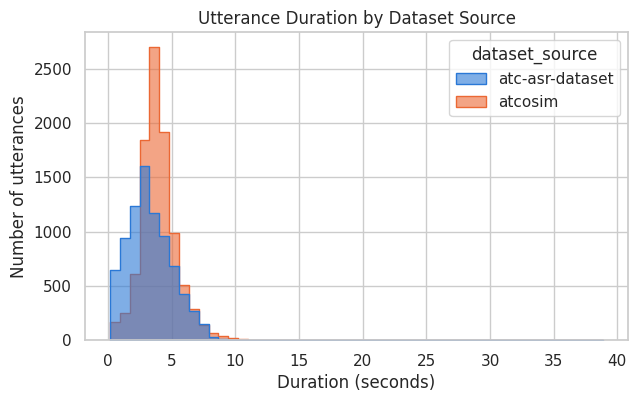

,mean,std,min,50%,max
dataset_source,,,,,
atc-asr-dataset,3.282198,1.728083,0.33000,3.05000,15.27000
atcosim,3.938160,1.508623,0.14075,3.77725,38.88125


In [29]:
# Fixed categorical color assignment, reused for every chart in this notebook.
HUE_ORDER = ["atc-asr-dataset", "atcosim"]
PALETTE = {"atc-asr-dataset": "#2a78d6", "atcosim": "#eb6834"}

fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(
    data=utterance_df, x="duration_sec", hue="dataset_source", hue_order=HUE_ORDER,
    palette=PALETTE, bins=50, alpha=0.6, element="step", ax=ax,
)
ax.set_title("Utterance Duration by Dataset Source")
ax.set_xlabel("Duration (seconds)")
ax.set_ylabel("Number of utterances")
save_fig(fig, "duration_by_source")
plt.show()

utterance_df.groupby("dataset_source")["duration_sec"].describe()[["mean", "std", "min", "50%", "max"]]

**Interpretation:** ATCOSIM clips run slightly longer on average (3.94s vs. 3.28s) and have a
much heavier tail: its max (38.9s) is over 2x `atc-asr-dataset`'s (15.3s). We investigate that
outlier specifically in the Outliers section below (spoiler: it's off-domain content, not a
processing error). Both distributions are unimodal and right-skewed, which is expected for
short spoken utterances.

Saved figure: ../res/figures/acoustic_features_by_source.png


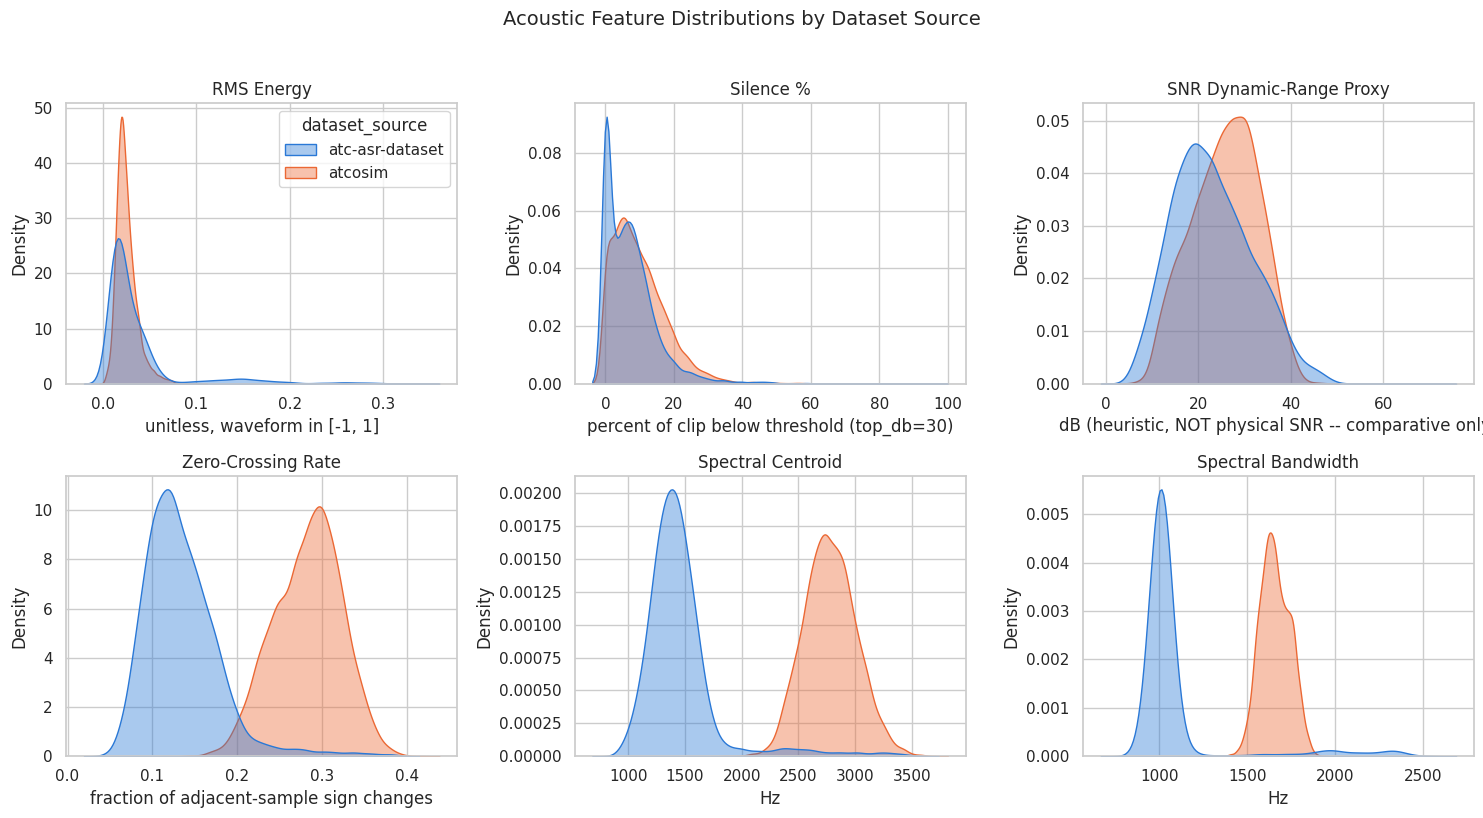

dataset_source,atc-asr-dataset,atcosim
rms_energy,0.036296,0.025310
silence_pct,7.181050,9.907002
snr_db_proxy,23.035985,25.774635
zero_crossing_rate,0.134522,0.283153
spectral_centroid_hz,1459.717370,2777.107716
spectral_bandwidth_hz,1086.902178,1656.585701


In [30]:
acoustic_features = [
    ("rms_energy", "RMS Energy", "unitless, waveform in [-1, 1]"),
    ("silence_pct", "Silence %", "percent of clip below threshold (top_db=30)"),
    ("snr_db_proxy", "SNR Dynamic-Range Proxy", "dB (heuristic, NOT physical SNR -- comparative only)"),
    ("zero_crossing_rate", "Zero-Crossing Rate", "fraction of adjacent-sample sign changes"),
    ("spectral_centroid_hz", "Spectral Centroid", "Hz"),
    ("spectral_bandwidth_hz", "Spectral Bandwidth", "Hz"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, (col, title, unit) in zip(axes.flat, acoustic_features):
    sns.kdeplot(
        data=utterance_df, x=col, hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, fill=True, alpha=0.4, common_norm=False, ax=ax, legend=(ax is axes.flat[0]),
    )
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.set_ylabel("Density")
fig.suptitle("Acoustic Feature Distributions by Dataset Source", y=1.02, fontsize=14)
fig.tight_layout()
save_fig(fig, "acoustic_features_by_source")
plt.show()

utterance_df.groupby("dataset_source")[[c for c, _, _ in acoustic_features]].mean().T

**Interpretation:** the clearest, most consistent pattern across all six features is that
`atc-asr-dataset` (real ATC radio audio) sits at **lower spectral centroid (1460 Hz vs. 2777
Hz), lower spectral bandwidth (1087 Hz vs. 1657 Hz), and lower zero-crossing rate (0.135 vs.
0.283)** than ATCOSIM: real ATC audio is transmitted over a narrowband VHF radio channel
(traditionally ~300–3400 Hz voice bandwidth), which filters out exactly the higher-frequency
content these three features measure, while ATCOSIM's simulated recordings are captured
full-bandwidth in a studio/lab setting with no radio-channel effect. This is a genuinely useful
finding for modeling: **a model trained mostly on ATCOSIM's clean, full-bandwidth audio is
learning a different acoustic distribution than it will see in real deployment**, which is
exactly the kind of domain gap this comparison is meant to surface.

`atc-asr-dataset` also shows higher RMS-energy *variance* (std 0.045 vs. 0.011), consistent
with real-world recording conditions (variable mic gain/distance, radio squelch bursts) that a
simulated corpus doesn't have. Its `snr_db_proxy` is slightly *lower* on average (23.0 dB vs.
25.8 dB), consistent with a noisier, less controlled background, though per the caveat in
`audio_features.py`, treat this as a comparative signal only, not a physical SNR measurement.

## Transcript Features: Length, Speech Rate, and Numeric Density

Saved figure: ../res/figures/transcript_features_by_source.png


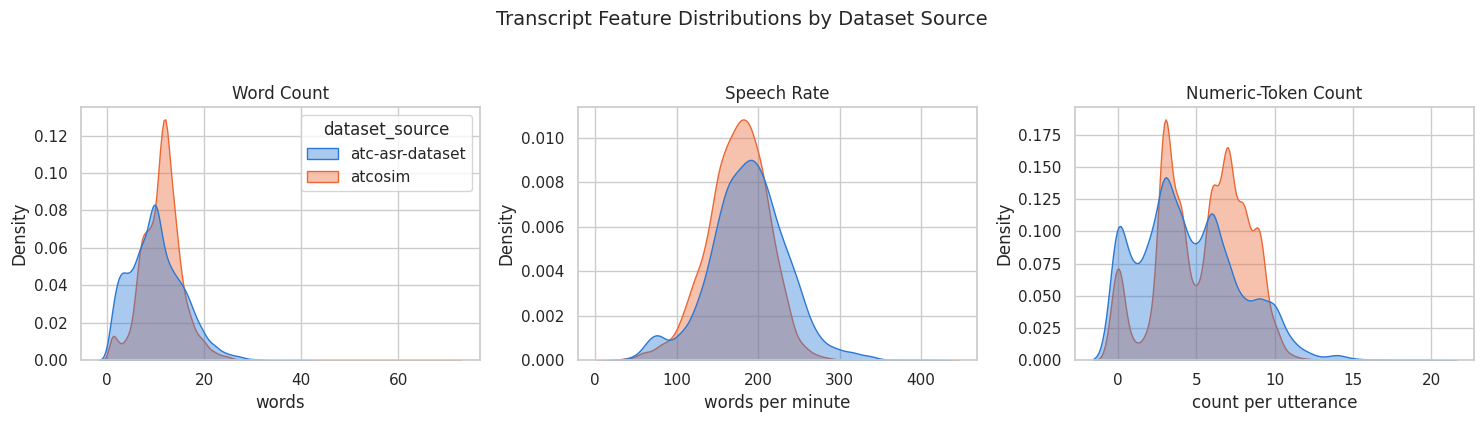

word_count           speech_rate_wpm             \
                      mean       std            mean        std   
dataset_source                                                    
atc-asr-dataset  10.182960  5.488097      187.712932  48.227625   
atcosim          11.289152  4.168641      174.404448  37.889498   

                numeric_token_count            
                               mean       std  
dataset_source                                 
atc-asr-dataset            4.507018  3.188262  
atcosim                    5.376399  2.706732

In [31]:
text_features_to_plot = [
    ("word_count", "Word Count", "words"),
    ("speech_rate_wpm", "Speech Rate", "words per minute"),
    ("numeric_token_count", "Numeric-Token Count", "count per utterance"),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, title, unit) in zip(axes, text_features_to_plot):
    sns.kdeplot(
        data=utterance_df, x=col, hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, fill=True, alpha=0.4, common_norm=False, ax=ax, legend=(ax is axes[0]),
    )
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.set_ylabel("Density")
fig.suptitle("Transcript Feature Distributions by Dataset Source", y=1.05, fontsize=14)
fig.tight_layout()
save_fig(fig, "transcript_features_by_source")
plt.show()

utterance_df.groupby("dataset_source")[[c for c, _, _ in text_features_to_plot]].agg(["mean", "std"])

In [32]:
# Vocabulary richness: distinct word types vs. total word tokens, per source.
vocab_stats = []
for source, group in utterance_df.groupby("dataset_source"):
    tokens = group["transcript_normalized"].str.split().explode()
    vocab_stats.append(
        {
            "dataset_source": source,
            "total_tokens": len(tokens),
            "distinct_types": tokens.nunique(),
            "type_token_ratio": tokens.nunique() / len(tokens),
        }
    )
pd.DataFrame(vocab_stats)

,dataset_source,total_tokens,distinct_types,type_token_ratio
0,atc-asr-dataset,82764,1167,0.014100
1,atcosim,107913,830,0.007691


**Interpretation:** ATCOSIM utterances are slightly longer by word count (11.3 vs. 10.2 words)
and have more total word tokens overall (107,913 vs. 82,764, reflecting its larger row count),
but a **much smaller and less varied vocabulary**: 830 distinct word types vs. 1,167 for
`atc-asr-dataset`, a type-token ratio of 0.0077 vs. 0.0141 (nearly 2x). This lines up directly
with the repeated-transcript finding above: ATCOSIM's simulated exercises draw from a smaller,
more repetitive phraseology set, while real-world ATC traffic (`atc-asr-dataset`) produces more
lexically varied transcripts even under standardized phraseology conventions.

`atc-asr-dataset` shows a *higher* mean speech rate (187.7 vs. 174.4 WPM) despite its shorter
average duration, plausibly reflecting real operational time pressure (controllers packing
information tightly) vs. more deliberately-paced simulated training speech. Both distributions
have a long right tail of very-high-WPM outliers, which the Outliers section below shows are a
known artifact of the WPM formula on very short (1-2 word) clips, not genuinely fast speech.

## Class Imbalance: Dataset Source Across Splits

Saved figure: ../res/figures/class_imbalance_split_source.png


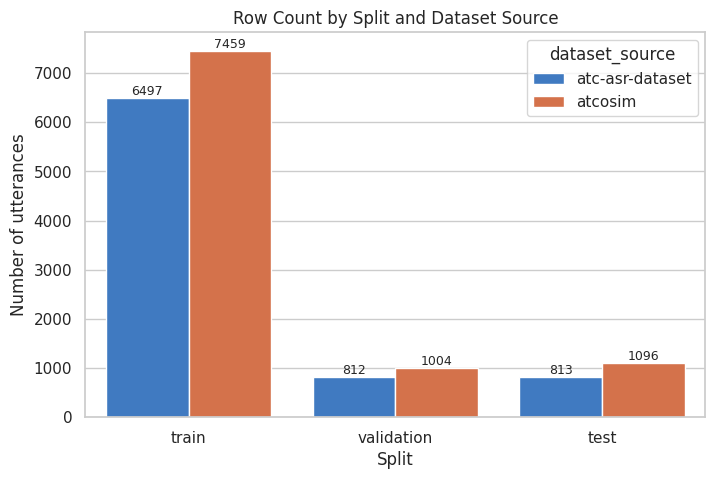

dataset_source,atc-asr-dataset,atcosim,total,pct_atc_asr_dataset
dataset_split,,,,
train,6497,7459,13956,46.6
validation,812,1004,1816,44.7
test,813,1096,1909,42.6


In [33]:
split_order = ["train", "validation", "test"]
split_counts = (
    utterance_df.groupby(["dataset_split", "dataset_source"]).size().rename("count").reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=split_counts, x="dataset_split", order=split_order, y="count",
    hue="dataset_source", hue_order=HUE_ORDER, palette=PALETTE, ax=ax,
)
ax.set_title("Row Count by Split and Dataset Source")
ax.set_xlabel("Split")
ax.set_ylabel("Number of utterances")
for container in ax.containers:
    ax.bar_label(container, fontsize=9)
save_fig(fig, "class_imbalance_split_source")
plt.show()

pivot = split_counts.pivot(index="dataset_split", columns="dataset_source", values="count").loc[split_order]
pivot["total"] = pivot.sum(axis=1)
pivot["pct_atc_asr_dataset"] = (100 * pivot["atc-asr-dataset"] / pivot["total"]).round(1)
pivot

**Interpretation:** the two sources are reasonably balanced within every split (`atc-asr-dataset`
is ~43-47% of each split's rows, `atcosim` the remainder); there's no split where one source
dominates so heavily that a model could ignore the other. The overall split proportions
(~79%/10%/11% train/validation/test) land close to, but not exactly, 80/10/10: `atc-asr-dataset`
is left untouched at its own near-exact 80/10/10 split, while ATCOSIM's session-grouped resplit
(see the Dataset Flow section) overshoots slightly, since its ~50 recording sessions can't be
divided into exactly-proportioned groups. That's an intentional, disclosed trade-off: exact
percentages in exchange for a test set with zero same-session leakage, not an error.

## Callsign/Command Proxy Distributions

**These are heuristic proxies, not ground-truth named-entity annotations**: real entity
extraction (Qwen-based NER, per the project plan) is a deferred follow-up. `command_verb_count`
and `callsign_like_count` come from fixed vocabulary/pattern matching (`preprocessing.vocab`,
`preprocessing.text_features`) and should be read as rough, comparative signals only.

Saved figure: ../res/figures/callsign_command_proxy_by_source.png


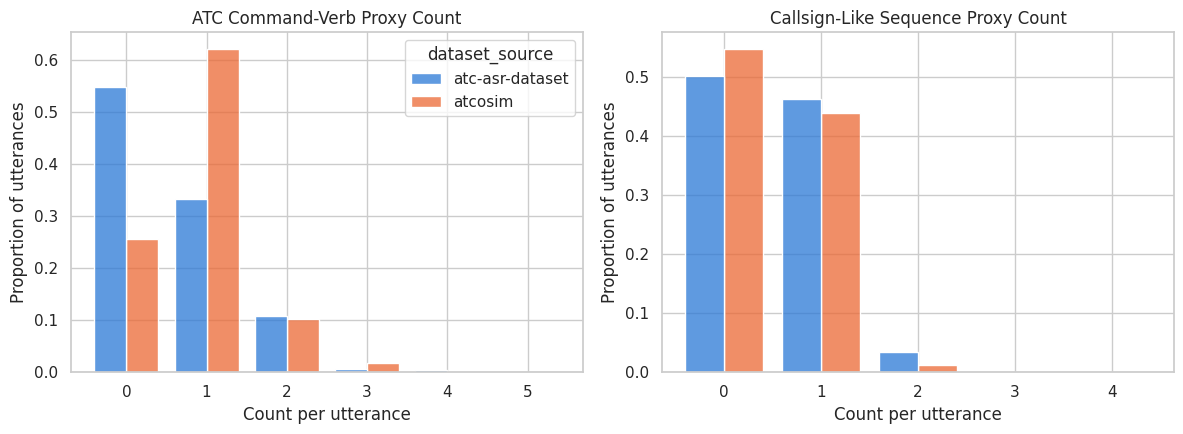

Share of rows with zero detections (proxy blind spot or genuinely absent):


,command_verb_count,callsign_like_count
dataset_source,,
atc-asr-dataset,0.548018,0.500985
atcosim,0.256721,0.548174


In [34]:
proxy_features = [
    ("command_verb_count", "ATC Command-Verb Proxy Count"),
    ("callsign_like_count", "Callsign-Like Sequence Proxy Count"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, (col, title) in zip(axes, proxy_features):
    sns.histplot(
        data=utterance_df, x=col, hue="dataset_source", hue_order=HUE_ORDER,
        palette=PALETTE, discrete=True, multiple="dodge", shrink=0.8, stat="proportion",
        common_norm=False, ax=ax, legend=(ax is axes[0]),
    )
    ax.set_title(title)
    ax.set_xlabel("Count per utterance")
    ax.set_ylabel("Proportion of utterances")
fig.tight_layout()
save_fig(fig, "callsign_command_proxy_by_source")
plt.show()

print("Share of rows with zero detections (proxy blind spot or genuinely absent):")
utterance_df.groupby("dataset_source")[["command_verb_count", "callsign_like_count"]].apply(
    lambda g: (g == 0).mean()
)

**Interpretation:** ATCOSIM has a much higher command-verb detection rate: only 25.7% of its
rows have zero detected command verbs, vs. **54.8%** for `atc-asr-dataset`. This is consistent
with everything else this notebook has found about the two sources: ATCOSIM's scripted training
scenarios emphasize standard instruction phraseology (climb/descend/maintain/contact/...) more
systematically, while real-world traffic (`atc-asr-dataset`) includes more short
acknowledgements, readbacks, and conversational filler with no command verb present at all.
Callsign-like detection is more similar between sources (~50% vs. ~55% zero-detection); this
proxy's fixed, non-exhaustive airline-word list (see `vocab.KNOWN_CALLSIGN_WORDS`) is the
likely limiting factor for *both* sources equally, which is exactly the kind of gap the deferred
LLM-based NER work is meant to close.

## Controller vs. Pilot Comparison: Not Applicable

Neither current source publishes a speaker-role field: `atcosim`'s Hugging Face mirror provides
only `audio`/`text`, and `atc-asr-dataset` provides only `id`/`audio`/`text` (both confirmed
directly against their schemas earlier in this notebook and in `docs/report.md`). There's no
reliable way to derive controller-vs-pilot role from the transcript alone without building a
real classifier, which would itself need labeled examples we don't have. This is answered
**N/A by design**, not a gap in this EDA: a heuristic guess here (e.g. "assume the first speaker
per session is the controller") would be unverifiable and could actively mislead later modeling
decisions, so it's better left undone than guessed at.

## Outliers

In [35]:
print("=== Longest utterances ===")
display(utterance_df.nlargest(3, "duration_sec")[["dataset_source", "duration_sec", "word_count", "transcript"]])

print("\n=== Shortest utterances ===")
display(utterance_df.nsmallest(5, "duration_sec")[["dataset_source", "duration_sec", "word_count", "transcript"]])

print(f"\n=== Zero-word-count rows: {(utterance_df['word_count'] == 0).sum()} ===")

print("\n=== Most extreme speech_rate_wpm (all from very short clips) ===")
display(utterance_df.nlargest(5, "speech_rate_wpm")[["dataset_source", "duration_sec", "word_count", "speech_rate_wpm"]])

=== Longest utterances ===


,dataset_source,duration_sec,word_count,transcript
5768,atcosim,38.881250,71,ah ah have a nice evening thank you bye by...
28,atcosim,20.603687,8,k l m three hundred kilo rhein identified
32,atcosim,19.240875,13,alitalia one one seven rhein identified olympi...



=== Shortest utterances ===


,dataset_source,duration_sec,word_count,transcript
2995,atcosim,0.140750,1,yeah
3117,atcosim,0.194875,1,yeah
6754,atcosim,0.232250,1,roge
6476,atcosim,0.237437,1,okay
7855,atcosim,0.243188,1,roger



=== Zero-word-count rows: 0 ===

=== Most extreme speech_rate_wpm (all from very short clips) ===


,dataset_source,duration_sec,word_count,speech_rate_wpm
7814,atcosim,0.280375,2,427.998217
2995,atcosim,0.140750,1,426.287744
13541,atc-asr-dataset,0.730000,5,410.958904
17130,atc-asr-dataset,0.730000,5,410.958904
12492,atc-asr-dataset,0.740000,5,405.405405


**Interpretation and retain/remove decisions:**

- **Longest utterance (38.9s, ATCOSIM):** the transcript is off-domain personal conversation
  ("...have a nice evening, thank you bye bye ciao... the irish pub... i really dont know i
  dont even know the address..."), not ATC phraseology at all. This looks like a
  simulation-session recording that captured incidental chatter rather than an operational
  exchange. **Decision: retain in the full corpus** (it's a legitimately recorded, correctly
  transcribed row, not corrupt data) **but flag it as a candidate to exclude from ASR
  training splits specifically**, since it isn't representative of the ATC-communication task
  the model is meant to learn. The next two longest rows are genuine (if long) operational
  ATC exchanges and don't need special handling.
- **Shortest utterances (~0.14-0.28s, single words like "yeah"/"roger"/"okay"):** genuine,
  very short acknowledgements, expected in ATC speech, not a processing error. One entry,
  `"roge"`, is very likely a transcription typo/truncation of "roger" in ATCOSIM's original
  transcript (not introduced by this pipeline), worth a note in the report as a known source
  imperfection, but not something to silently "fix" by guessing the intended word.
- **Zero-word-count rows: 0.** No blank-after-decode transcripts exist in the final corpus.
- **Extreme speech-rate outliers (400+ WPM):** every one of these comes from a 1-2 word,
  sub-second clip, a known mathematical artifact of `speech_rate_wpm = word_count /
  (duration_sec / 60)`: dividing by a very small duration inflates the rate regardless of
  actual speaking speed. **Decision: retain the rows** (the underlying audio/transcript is
  fine), but **treat `speech_rate_wpm` as unreliable below ~1 second of audio** in any later
  analysis or modeling that uses it as a feature.

### Z-Score Distributions

The tables above find individual extreme rows; the chart below places the whole distribution
against a **fixed** standard-normal bell curve for context. Every column is converted to
z-scores (`(value - mean) / std`) before plotting, so the curve itself never changes shape from
column to column, only where a given column's data actually falls on it does. That makes it a
fair way to eyeball how outlier-heavy `duration_sec` is relative to `speech_rate_wpm` at a
glance, using the same visual scale for both:

- Shaded bands mark the standard ±1σ (68%), ±2σ (95%), and beyond-±2σ (which
  contains the ±3σ, 99.7%, boundary) regions of a normal distribution.
- Solid/dashed/dotted vertical lines mark the mean, median, and mode. Mean is always at 0σ by
  construction; how far median and mode drift from it is a quick visual read on skew.
- The x-axis is padded a little past ±3σ to show real near-tail points rather than clipping
  them at the 3σ gridline. Since both columns have far more extreme outliers than would fit in
  a readable plot (`duration_sec`'s single 38.9s row is over 18σ out), the axis is capped at a
  reasonable padding limit and everything beyond it is collapsed to the edge and annotated with
  a count, rather than stretching the whole chart to fit one extreme point.
- Small tick marks along the bottom show individual rows beyond ±2σ (blue) and beyond ±3σ
  (red), the same rows the tables above are already looking at.

In [ ]:
from scipy.stats import gaussian_kde, norm

GOOD, WARNING, CRITICAL = "#0ca30c", "#fab219", "#d03b3b"
RUG_ELEVATED, RUG_EXTREME = "#2a78d6", "#d03b3b"


def plot_zscore_distribution(ax, values, title, unit="", curve_color="#2a78d6"):
    """Plot a fixed standard-normal bell curve with 1/2-sigma bands, then place `values`'
    mean, median, mode, and individual tail points on it as z-scores. The curve shape never
    changes across columns; only where the markers fall does.
    """
    values = pd.Series(values).dropna()
    mean, std = values.mean(), values.std()
    median = values.median()

    kde = gaussian_kde(values)
    grid = np.linspace(values.min(), values.max(), 2000)
    mode = grid[np.argmax(kde(grid))]

    z = (values - mean) / std
    z_median = (median - mean) / std
    z_mode = (mode - mean) / std

    pad = float(np.clip(np.abs(z).max(), 3.5, 5.0))
    x = np.linspace(-pad, pad, 600)
    pdf = norm.pdf(x)

    ax.fill_between(x, pdf, where=(np.abs(x) <= 1), color=GOOD, alpha=0.35, lw=0)
    ax.fill_between(x, pdf, where=(np.abs(x) > 1) & (np.abs(x) <= 2), color=WARNING, alpha=0.35, lw=0)
    ax.fill_between(x, pdf, where=(np.abs(x) > 2), color=CRITICAL, alpha=0.35, lw=0)
    ax.plot(x, pdf, color=curve_color, lw=2, zorder=3)

    elevated = z[(z.abs() > 2) & (z.abs() <= 3)].clip(-pad, pad)
    extreme = z[z.abs() > 3].clip(-pad, pad)
    rug_y = -0.035 * pdf.max()
    ax.plot(elevated, np.full(len(elevated), rug_y), "|", color=RUG_ELEVATED, alpha=0.5, markersize=10, mew=1)
    ax.plot(extreme, np.full(len(extreme), rug_y), "|", color=RUG_EXTREME, alpha=0.6, markersize=10, mew=1)

    ax.axvline(0, color="#0b0b0b", lw=1.5, linestyle="-", label=f"Mean = {mean:.2f}{unit}")
    ax.axvline(z_median, color="#0b0b0b", lw=1.5, linestyle="--", label=f"Median = {median:.2f}{unit}")
    ax.axvline(z_mode, color="#0b0b0b", lw=1.5, linestyle=":", label=f"Mode = {mode:.2f}{unit}")

    n_beyond_right = int((z > pad).sum())
    n_beyond_left = int((z < -pad).sum())
    if n_beyond_right:
        ax.annotate(
            f"+{n_beyond_right} more beyond +{pad:.0f}σ\n(up to {values.max():.1f}{unit})",
            xy=(pad, pdf.max() * 0.05), xytext=(pad - 1.6, pdf.max() * 0.55),
            fontsize=8, color=CRITICAL, ha="center",
            arrowprops=dict(arrowstyle="->", color=CRITICAL, lw=1),
        )
    if n_beyond_left:
        ax.annotate(
            f"+{n_beyond_left} more beyond -{pad:.0f}σ\n(down to {values.min():.1f}{unit})",
            xy=(-pad, pdf.max() * 0.05), xytext=(-pad + 1.6, pdf.max() * 0.55),
            fontsize=8, color=CRITICAL, ha="center",
            arrowprops=dict(arrowstyle="->", color=CRITICAL, lw=1),
        )

    ticks = np.arange(-np.floor(pad), np.floor(pad) + 1)
    ax.set_xticks(ticks)
    ax.set_xticklabels(["0σ" if t == 0 else f"{t:+.0f}σ" for t in ticks])
    ax.set_xlim(-pad, pad)
    ax.set_ylim(bottom=rug_y * 1.4)
    ax.set_title(title)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8, loc="upper right")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_zscore_distribution(axes[0], utterance_df["duration_sec"], "Utterance Duration", unit="s")
plot_zscore_distribution(axes[1], utterance_df["speech_rate_wpm"], "Speech Rate", unit=" WPM")

band_handles = [
    plt.Rectangle((0, 0), 1, 1, color=GOOD, alpha=0.35, label="±1σ (68%)"),
    plt.Rectangle((0, 0), 1, 1, color=WARNING, alpha=0.35, label="±2σ (95%)"),
    plt.Rectangle((0, 0), 1, 1, color=CRITICAL, alpha=0.35, label="±3σ+ (99.7%)"),
]
fig.legend(handles=band_handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.02), fontsize=9, frameon=False)
fig.tight_layout()
save_fig(fig, "outlier_zscore_distributions")
plt.show()

**Interpretation:** both distributions are visibly right-skewed on this chart, the median and
mode sit slightly left of the mean (a long right tail pulls the mean past the bulk of the
data), which matches the "heavier tail" and "long right tail" findings already called out for
`duration_sec` and `speech_rate_wpm` earlier in this notebook. The points flagged beyond ±2σ
here are the same rows the tables above already identify individually (the 38.9s ATCOSIM
outlier, the sub-second/400+ WPM clips): this chart adds the distributional context for *how
unusual* those rows are relative to the rest of the corpus, not a new set of outliers.

## Summary of Findings and Modeling Implications

**Data quality.** The final corpus (17,681 utterances) is clean: 0 corrupt-audio rows, 0
missing transcripts, 0 true duplicate recordings, and every column matches the documented
final schema. 3,691 rows (20.9%) carry a legitimately repeated transcript, retained, not a
defect, with a markedly higher rate in ATCOSIM (31.6%) than `atc-asr-dataset` (8.2%).

**The dominant signal in every section above is the same real-vs-simulated domain gap,
approached from four different angles that all agree:**

1. **Acoustics:** `atc-asr-dataset` (real, radio-transmitted) has a lower spectral centroid,
   lower bandwidth, and lower zero-crossing rate than ATCOSIM (simulated, full-bandwidth),
   consistent with real ATC audio passing through a narrowband VHF radio channel that
   ATCOSIM's clean studio recordings never do. It also has higher RMS-energy variance,
   consistent with uncontrolled real-world recording conditions.
2. **Vocabulary:** `atc-asr-dataset` has a much richer vocabulary (1,167 distinct word types,
   type-token ratio 0.0141) than ATCOSIM (830 types, ratio 0.0077): real-world traffic is
   lexically more varied than scripted simulation exercises.
3. **Phraseology structure:** ATCOSIM's transcripts have a much higher rate of detected
   command verbs (74.3% of rows vs. 45.2% for `atc-asr-dataset`) and repeated transcripts
   (31.6% vs. 8.2%): its scripted scenarios lean on a smaller, more standardized set of
   instructions.
4. **Speech rate:** `atc-asr-dataset` is spoken faster on average (187.7 vs. 174.4 WPM) despite
   shorter clips, plausibly real operational time pressure vs. more deliberately-paced
   training speech.

**Modeling implications:**
- A model trained predominantly on ATCOSIM will see a narrower acoustic distribution
  (full-bandwidth, clean, less-varied vocabulary) than it will encounter in real deployment;
  this comparison exists specifically to make that domain gap visible before training starts,
  not after.
- `speech_rate_wpm` should be treated as unreliable on sub-1-second clips; any model or
  analysis that uses it as a feature should either filter those rows or use a
  duration-weighted variant.
- The one identified off-domain outlier (the 38.9s ATCOSIM personal-conversation row) is a
  concrete candidate to exclude specifically from training/eval splits (not from the EDA
  corpus) before model training begins.
- `command_verb_count`/`callsign_like_count` are useful *comparative* signals for this EDA but
  are not a substitute for the deferred, ground-truth NER work; don't treat their absolute
  values as entity ground truth in later modeling.